In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
from sklearn.linear_model  import LinearRegression
from sklearn.model_selection import train_test_split

In [41]:
#loading the datasets
df=pd.read_csv("Experience-Salary.csv")
df.head()

,exp(in months),salary(in thousands)
0,18.290293,16.521825
1,17.023407,11.666234
2,26.343613,23.167255
3,19.105834,20.877145
4,27.742516,23.166236


In [42]:
#Understanding our datasets
df.shape

(1000, 2)

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   exp(in months)        1000 non-null   float64
 1   salary(in thousands)  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [44]:
df.isnull().sum()

exp(in months)          0
salary(in thousands)    0
dtype: int64

In [45]:
df.describe()

,exp(in months),salary(in thousands)
count,1000.000000,1000.000000
mean,26.157825,26.722597
std,8.717091,8.844761
min,0.697594,-1.276342
25%,20.073600,20.531008
50%,25.875225,26.745576
75%,32.406986,32.615753
max,49.463222,55.297016


In [46]:
#Checking corelation
#means there is a strong positive linear relationship between experience and salary.
df["exp(in months)"].corr(df["salary(in thousands)"])

np.float64(0.8109692945840655)

In [47]:
#Defining X an y
X=df[["exp(in months)"]]
y=df[["salary(in thousands)"]]

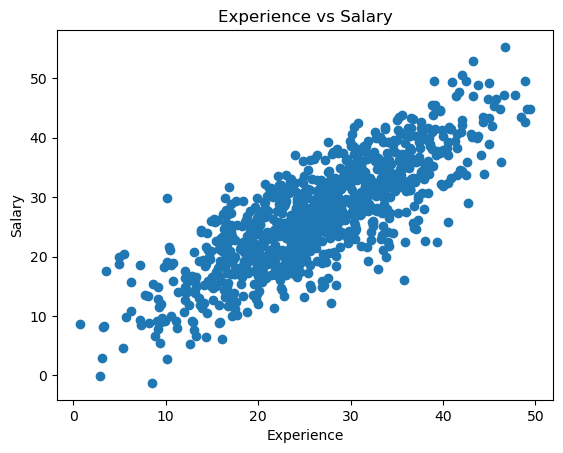

In [48]:
#Visualize the data
plt.scatter(X,y)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [49]:
#Splitting the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [50]:
#Checking the sizes
print("Training data: ",X_train.shape)
print("testing data: ",X_test.shape)

Training data:  (800, 1)
testing data:  (200, 1)


In [51]:
#Creation of model
model=LinearRegression()

In [52]:
#Fitting the data
model.fit(X_train,y_train)

LinearRegression()

In [53]:
#getting coefficient and intercept
print("Slope(Coefficient): ",model.coef_[0])
print("Intercept: ",model.intercept_)

Slope(Coefficient):  [0.82359128]
Intercept:  [5.21221496]


In [54]:
#making a prediction
y_pred=model.predict(X_test)

In [55]:
#Comapring the predicted and actual values
y_test_1d=y_test.to_numpy().ravel()
y_pred_1d=y_pred.ravel()
comparision=pd.DataFrame({
    "Actual Salaray":y_test_1d,
    "Predicted Salary":y_pred_1d
})
comparision.head(10)

,Actual Salaray,Predicted Salary
0,21.082275,23.853567
1,19.331912,26.965086
2,26.858661,22.321617
3,26.781741,26.010901
4,36.203149,34.194467
5,8.356293,7.961212
6,36.214557,30.753892
7,38.594141,31.294073
8,22.773603,31.732824
9,23.638539,25.479801


In [56]:
#Evaluating the model
mae=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error: ",mae)
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)
rmse=np.sqrt(mse)
print("Root Mean Squared Error:",rmse)
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)


Mean Absolute Error:  4.160807280303731
Mean Squared Error: 27.522680093271664
Root Mean Squared Error: 5.246206257217844
R2 Score: 0.6484072054017384


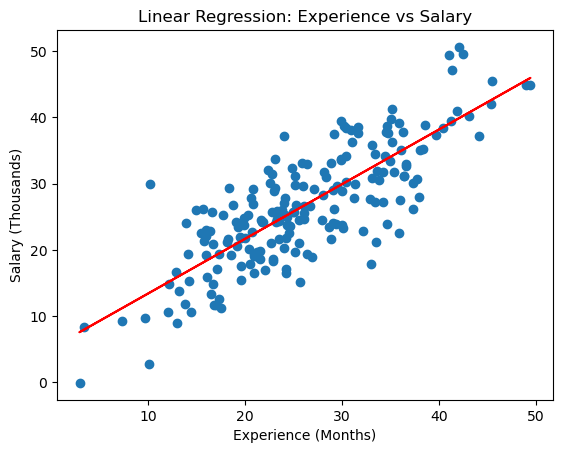

In [60]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred,color="red")

plt.xlabel("Experience (Months)")
plt.ylabel("Salary (Thousands)")
plt.title("Linear Regression: Experience vs Salary")
plt.show()

In [58]:
#Predicting a new value
experience = float(input("Enter your experience in months: "))
new_data = pd.DataFrame({
    "exp(in months)": [experience]
})
# Predicting salary
predicted_salary = model.predict(new_data)
print("Predicted Salary:", predicted_salary[0], "thousand")

Predicted Salary: [24.36282068] thousand
